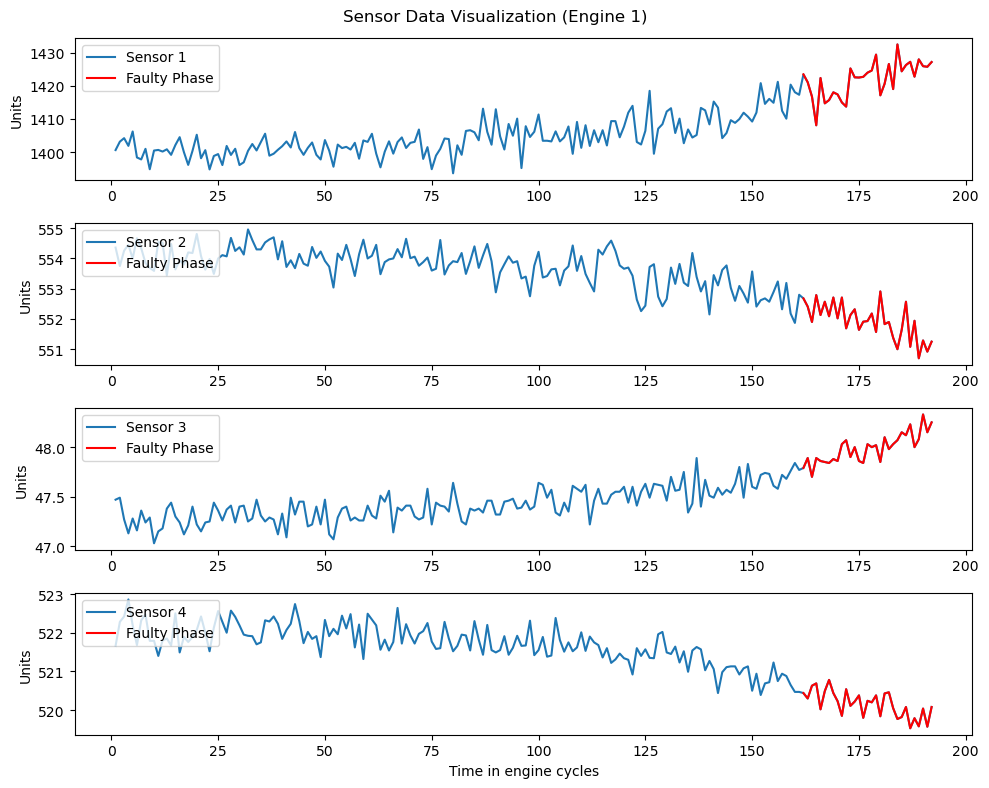

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the datasets provided in the assignment description [cite: 26, 31, 33]
train = pd.read_csv('train_selected.csv')
test = pd.read_csv('test_selected.csv')
# 'PM_truth.txt' contains the actual TTF values for the test engines [cite: 33]
truth = pd.read_csv('PM_truth.txt', header=None, names=['TTF_True'])

# Visualizing Sensor Data for Engine 1 as required [cite: 28, 29]
engine1 = train[train['id'] == 1]
plt.figure(figsize=(10, 8))
for i in range(1, 5):
    plt.subplot(4, 1, i)
    plt.plot(engine1['cycle'], engine1[f's{i}'], label=f'Sensor {i}')
    # Highlight the 'faulty' period (last 30 cycles) [cite: 30]
    faulty_period = engine1[engine1['label_bnc'] == 1]
    plt.plot(faulty_period['cycle'], faulty_period[f's{i}'], 'r', label='Faulty Phase')
    plt.ylabel('Units')
    plt.legend(loc='upper left')

plt.xlabel('Time in engine cycles')
plt.suptitle('Sensor Data Visualization (Engine 1)')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features: 4 sensor measurements [cite: 26]
X_train = train[['s1', 's2', 's3', 's4']]
y_train = train['ttf']

# Model Selection: Linear Regression [cite: 36, 42]
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# For testing, we use the last available sensor reading for each engine in the test set [cite: 31]
X_test_last = test.groupby('id').last()[['s1', 's2', 's3', 's4']]
y_pred_ttf = reg_model.predict(X_test_last)

# Evaluate using RMSE (Quantitative metric) [cite: 38, 61]
rmse = np.sqrt(mean_squared_error(truth['TTF_True'], y_pred_ttf))
print(f"Regression RMSE: {rmse:.2f}")

Regression RMSE: 35.33


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Using a Random Forest Classifier for robust binary classification [cite: 39]
y_train_class = train['label_bnc']
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train_class)

# Predict failure for the test engines
y_pred_class = clf_model.predict(X_test_last)

# Ground Truth: An engine is 'faulty' (1) if its true TTF is 30 or less [cite: 30, 33]
y_test_truth = (truth['TTF_True'] <= 30).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test_truth, y_pred_class))
print("\nClassification Report:")
print(classification_report(y_test_truth, y_pred_class))

Confusion Matrix:
[[73  2]
 [ 8 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94        75
           1       0.89      0.68      0.77        25

    accuracy                           0.90       100
   macro avg       0.90      0.83      0.85       100
weighted avg       0.90      0.90      0.90       100

